In [14]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu, sobel
from skimage.segmentation import mark_boundaries
from skimage.feature import graycomatrix
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [15]:
def show_images(images, titles, rows=1, cols=2, cmap=None, figsize=(12, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), 1):
        plt.subplot(rows, cols, i)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

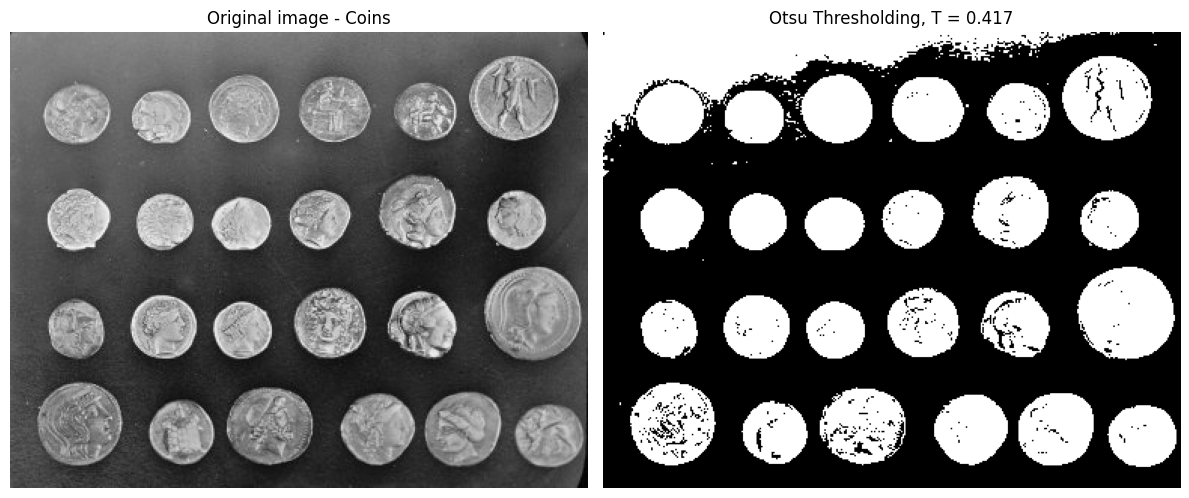

Discussion:

Otsu thresholding separates the image into foreground and background using one global threshold.
In this image, coins are mostly separated from the darker background.
However, some errors can appear because of shadows, texture, and different illumination.



In [16]:
# Task 1: Thresholding segmentation

coins = img_as_float(data.coins())

threshold = threshold_otsu(coins)
binary_coins = coins > threshold

show_images(
    [coins, binary_coins],
    ["Original image - Coins", f"Otsu Thresholding, T = {threshold:.3f}"],
    rows=1,
    cols=2,
    cmap="gray",
    figsize=(12, 5)
)

print("Discussion:")
print("""
Otsu thresholding separates the image into foreground and background using one global threshold.
In this image, coins are mostly separated from the darker background.
However, some errors can appear because of shadows, texture, and different illumination.
""")

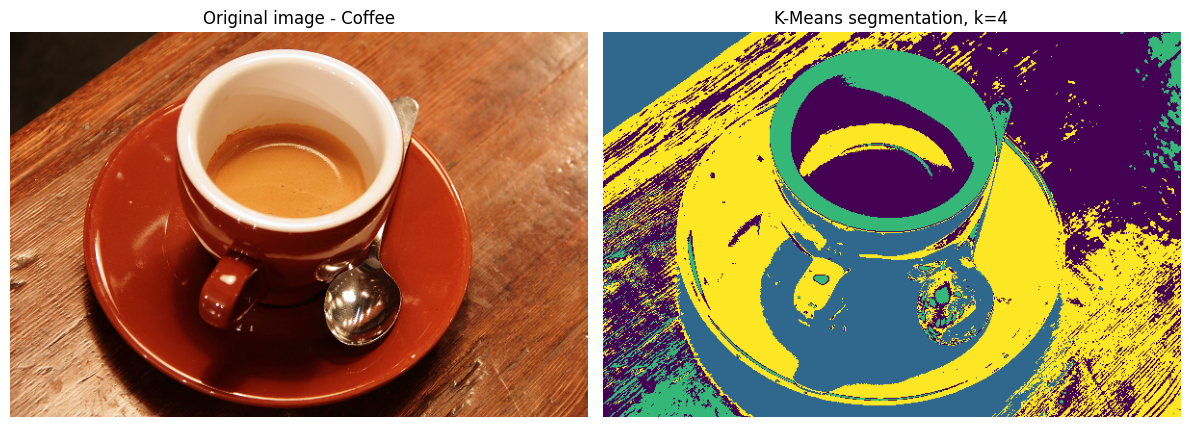

Discussion:

K-Means groups pixels based on color similarity without using labels.
The segmentation separates main color regions such as cup, background, and coffee area.
The result depends strongly on the selected number of clusters.
It does not understand objects semantically; it only groups similar colors.



In [17]:
# Task 2: Unsupervised segmentation using K-Means

coffee = img_as_float(data.coffee())

pixels = coffee.reshape(-1, 3)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)

segmented_kmeans = labels.reshape(coffee.shape[:2])

show_images(
    [coffee, segmented_kmeans],
    ["Original image - Coffee", "K-Means segmentation, k=4"],
    rows=1,
    cols=2,
    cmap="viridis",
    figsize=(12, 5)
)

print("Discussion:")
print("""
K-Means groups pixels based on color similarity without using labels.
The segmentation separates main color regions such as cup, background, and coffee area.
The result depends strongly on the selected number of clusters.
It does not understand objects semantically; it only groups similar colors.
""")

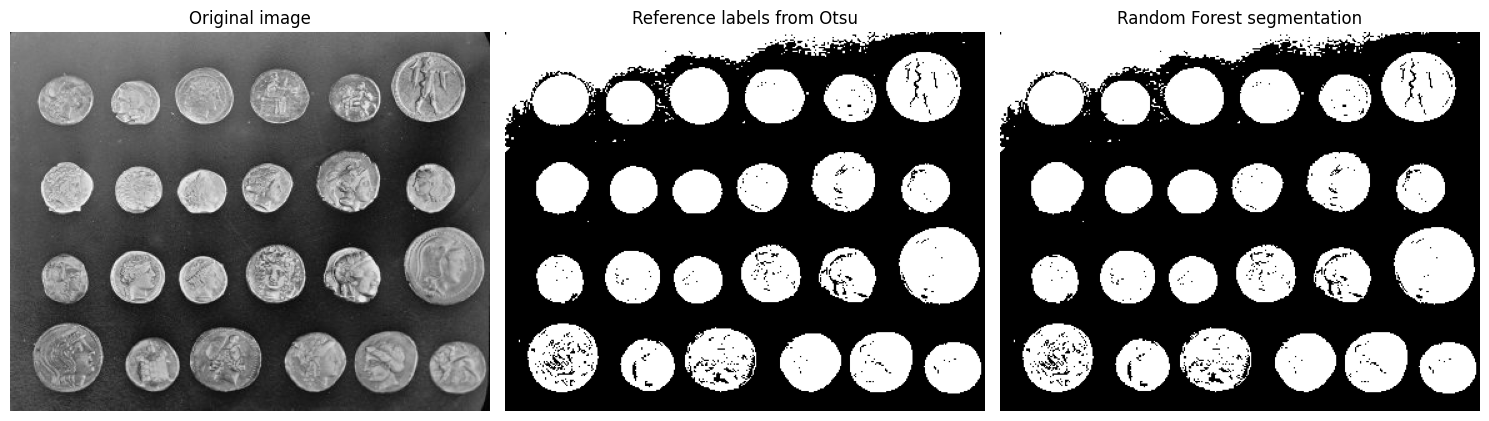

Test accuracy: 1.0000
Discussion:

The supervised method learns from labeled pixels and predicts the class of each pixel.
Here, labels are created using Otsu thresholding, so the classifier learns a coin/background separation.
The result is good because the classes have different intensity and edge characteristics.
A limitation is that supervised segmentation needs labeled data. If labels are poor, the classifier also learns poor segmentation.



In [18]:
# Task 3: Supervised segmentation using a classifier

image = img_as_float(data.coins())
gray = image

# Create simple labels automatically using Otsu threshold
# 1 = object/coin, 0 = background
labels = (gray > threshold_otsu(gray)).astype(int)

# Feature extraction
edge_feature = sobel(gray)

rows, cols = gray.shape
rr, cc = np.meshgrid(
    np.linspace(0, 1, rows),
    np.linspace(0, 1, cols),
    indexing="ij"
)

X = np.stack([
    gray.ravel(),
    edge_feature.ravel(),
    rr.ravel(),
    cc.ravel()
], axis=1)

y = labels.ravel()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

clf.fit(X_train, y_train)

y_pred_test = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred_test)

# Predict full image
full_prediction = clf.predict(X)
segmented_rf = full_prediction.reshape(gray.shape)

show_images(
    [gray, labels, segmented_rf],
    ["Original image", "Reference labels from Otsu", "Random Forest segmentation"],
    rows=1,
    cols=3,
    cmap="gray",
    figsize=(15, 5)
)

print(f"Test accuracy: {acc:.4f}")

print("Discussion:")
print("""
The supervised method learns from labeled pixels and predicts the class of each pixel.
Here, labels are created using Otsu thresholding, so the classifier learns a coin/background separation.
The result is good because the classes have different intensity and edge characteristics.
A limitation is that supervised segmentation needs labeled data. If labels are poor, the classifier also learns poor segmentation.
""")

In [19]:
print("""
Task 4: Supervised vs Unsupervised Segmentation

Unsupervised segmentation:
- Does not require labeled data.
- Groups pixels based on similarity, for example color or intensity.
- Example: K-Means segmentation on the coffee image.
- Advantage: easy to apply when no annotations are available.
- Disadvantage: the result depends on parameters such as number of clusters, and it does not understand real object classes.

Supervised segmentation:
- Requires labeled data for training.
- A classifier learns the relationship between pixel features and classes.
- Example: Random Forest segmentation for separating coins from background.
- Advantage: can be more accurate when good labels are available.
- Disadvantage: labeling data is time-consuming and the model depends on the quality of annotations.

In summary:
K-Means discovers groups automatically, while Random Forest learns from examples.
""")


Task 4: Supervised vs Unsupervised Segmentation

Unsupervised segmentation:
- Does not require labeled data.
- Groups pixels based on similarity, for example color or intensity.
- Example: K-Means segmentation on the coffee image.
- Advantage: easy to apply when no annotations are available.
- Disadvantage: the result depends on parameters such as number of clusters, and it does not understand real object classes.

Supervised segmentation:
- Requires labeled data for training.
- A classifier learns the relationship between pixel features and classes.
- Example: Random Forest segmentation for separating coins from background.
- Advantage: can be more accurate when good labels are available.
- Disadvantage: labeling data is time-consuming and the model depends on the quality of annotations.

In summary:
K-Means discovers groups automatically, while Random Forest learns from examples.

